In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
# Fear Dataset
fear = pd.read_csv('fear_greed_index.csv')
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [14]:
# Trader Dataset
trades = pd.read_csv('historical_data.csv')
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [15]:
# Convert dates of fear dataset
fear['date'] = pd.to_datetime(fear['date'])

In [16]:
# Convert dates of Trader dataset
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.date
fear['date'] = fear['date'].dt.date

#### Merge both datasets

In [17]:
merged = pd.merge(
  trades, fear, on='date', how='left'
)

In [18]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


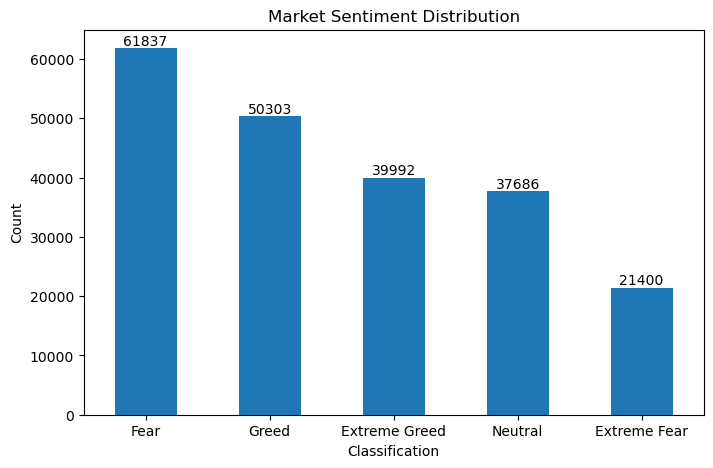

In [19]:
counts = merged['classification'].value_counts()

ax = counts.plot(kind='bar', figsize=(8,5))

plt.title('Market Sentiment Distribution')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Add labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

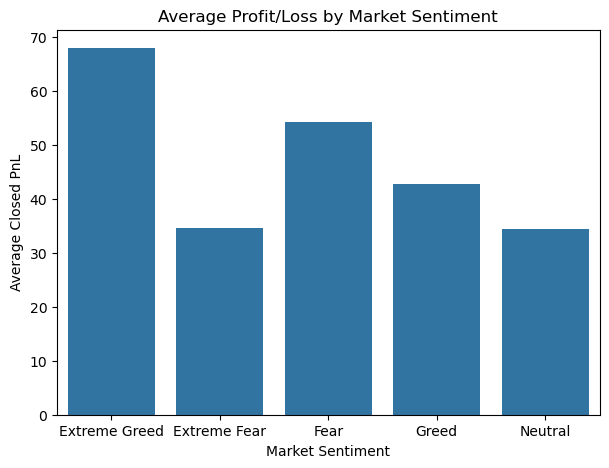

In [20]:
# Average Profit/Loss

plt.figure(figsize=(7,5))

sns.barplot(
    data=merged,
    x='classification',
    y='Closed PnL',
    estimator='mean',
    errorbar=None
)

plt.title('Average Profit/Loss by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')

plt.show()

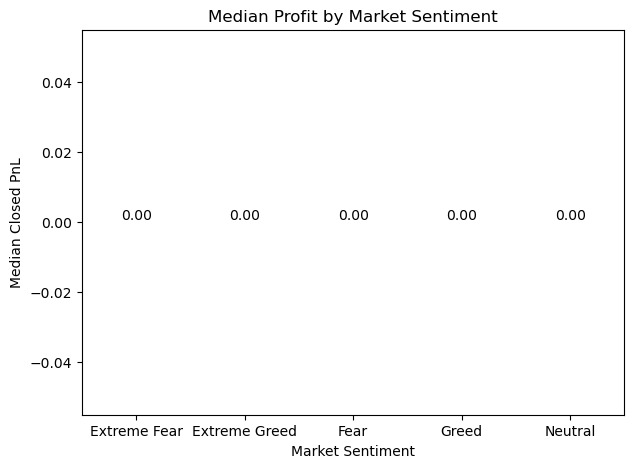

In [21]:
# Median Profit
median_pnl = merged.groupby('classification')['Closed PnL'].median()

ax = median_pnl.plot(kind='bar', figsize=(7,5))

plt.title('Median Profit by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Median Closed PnL')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

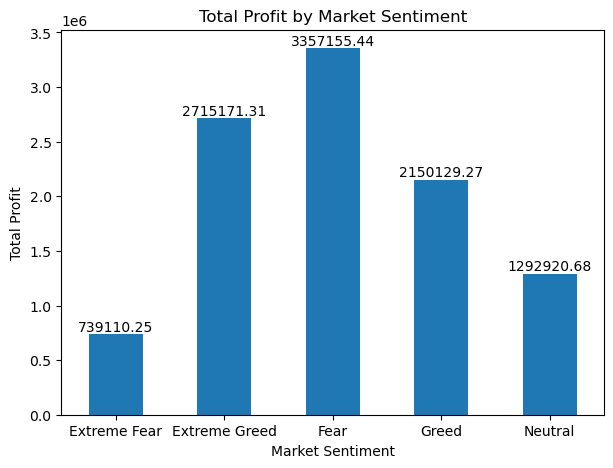

In [22]:
# Total Profit
total_profit = merged.groupby('classification')['Closed PnL'].sum()

ax = total_profit.plot(kind='bar', figsize=(7,5))

plt.title('Total Profit by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)

for container in ax.containers:
  ax.bar_label(container, fmt='%.2f')

plt.show()

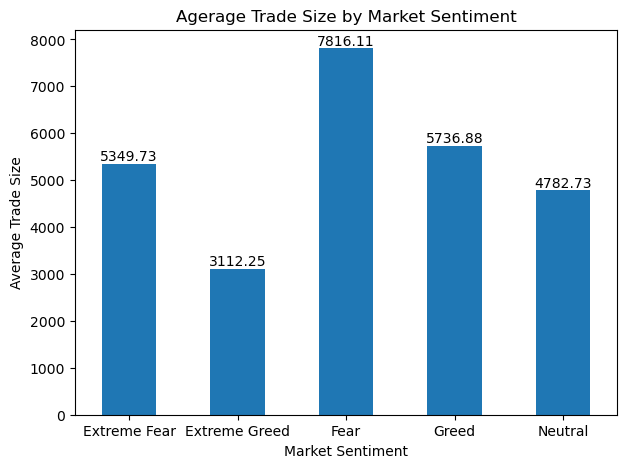

In [ ]:
# Average Trade Size
average_trade_size = merged.groupby("classification")['Size USD'].mean()

ax = average_trade_size.plot(kind='bar', figsize=(7,5))

plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Trade Size')
plt.xticks(rotation=0)

for container in ax.containers:
  ax.bar_label(container, fmt='%.2f')

plt.show()

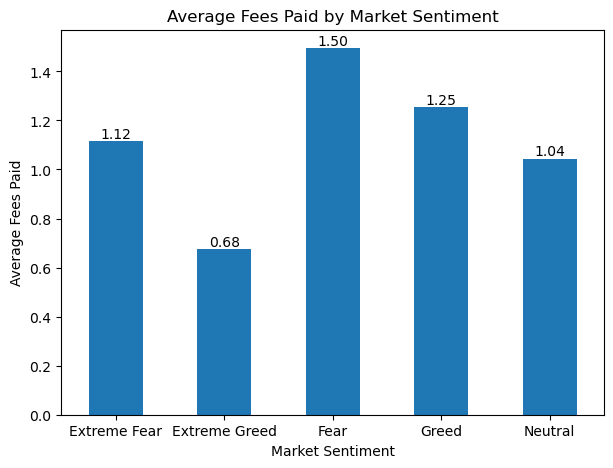

In [25]:
# Average Fees Paid
average_fees_paid = merged.groupby("classification")['Fee'].mean()

ax = average_fees_paid.plot(kind='bar', figsize=(7,5))

plt.title('Average Fees Paid by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Fees Paid')
plt.xticks(rotation=0)

for container in ax.containers:
  ax.bar_label(container, fmt='%.2f')

plt.show()

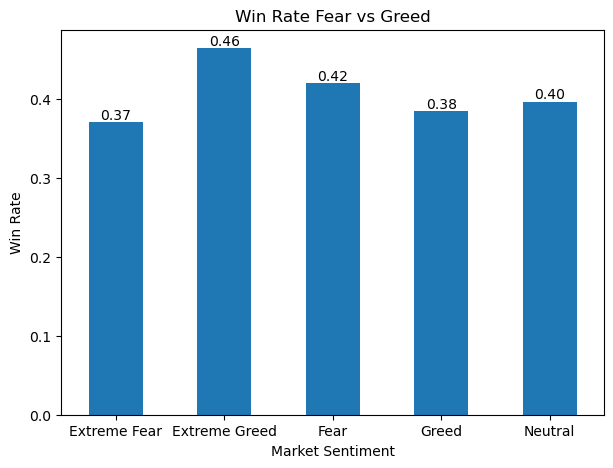

In [28]:
# Win Percentage during Fear vs Greed

merged['Win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('classification')['Win'].mean()

ax = win_rate.plot(kind='bar',figsize=(7,5))

plt.title('Win Rate Fear vs Greed')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate')
plt.xticks(rotation=0)

for container in ax.containers:
  ax.bar_label(container, fmt='%.2f')

plt.show()

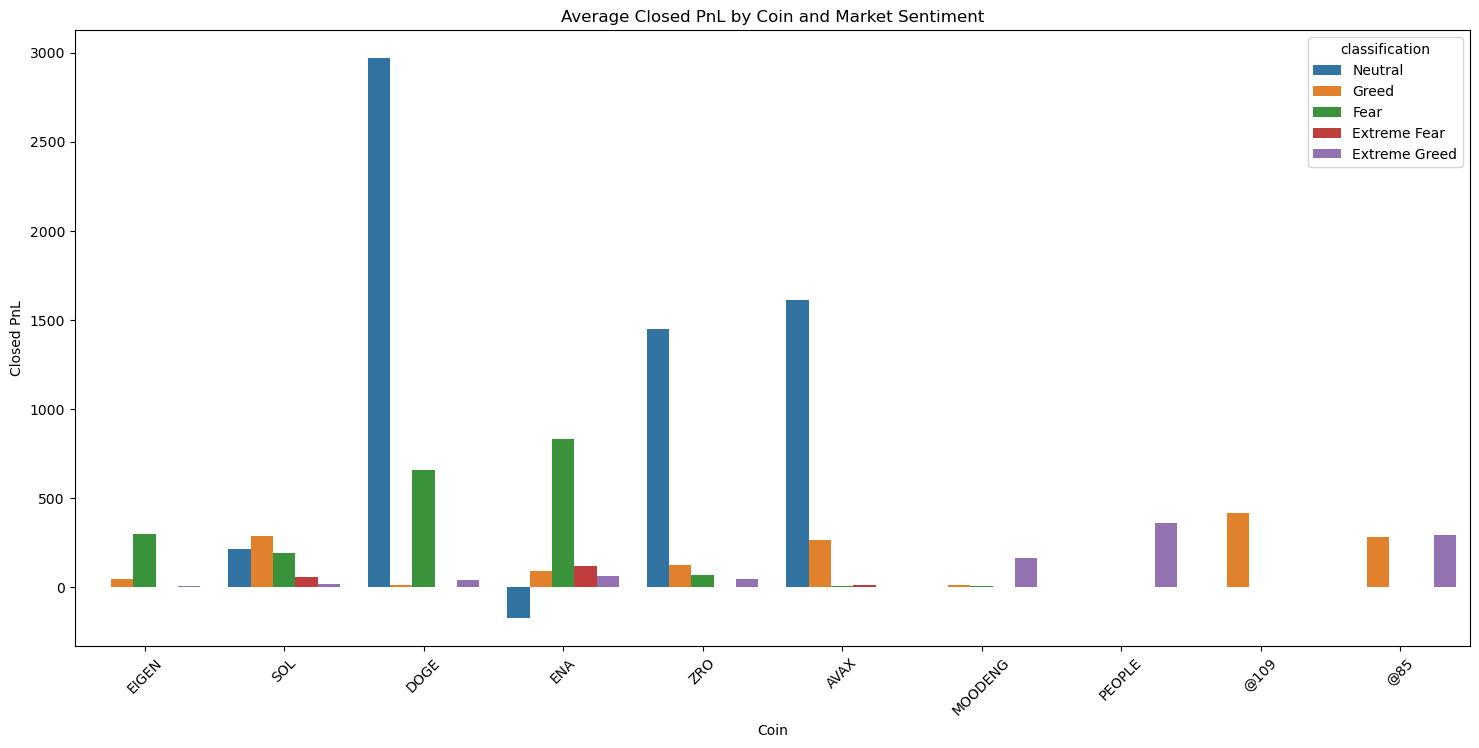

In [72]:
# Coin Analysis
top10 = (
    merged.groupby('Coin')['Closed PnL']
    .mean()
    .nlargest(10)
    .index
)

subset = merged[merged['Coin'].isin(top10)]

plt.figure(figsize=(18,8))

sns.barplot(
    data=subset,
    x='Coin',
    y='Closed PnL',
    hue='classification',
    estimator='mean',
    errorbar=None
)

plt.title('Average Closed PnL by Coin and Market Sentiment')
plt.xticks(rotation=45)
plt.show()

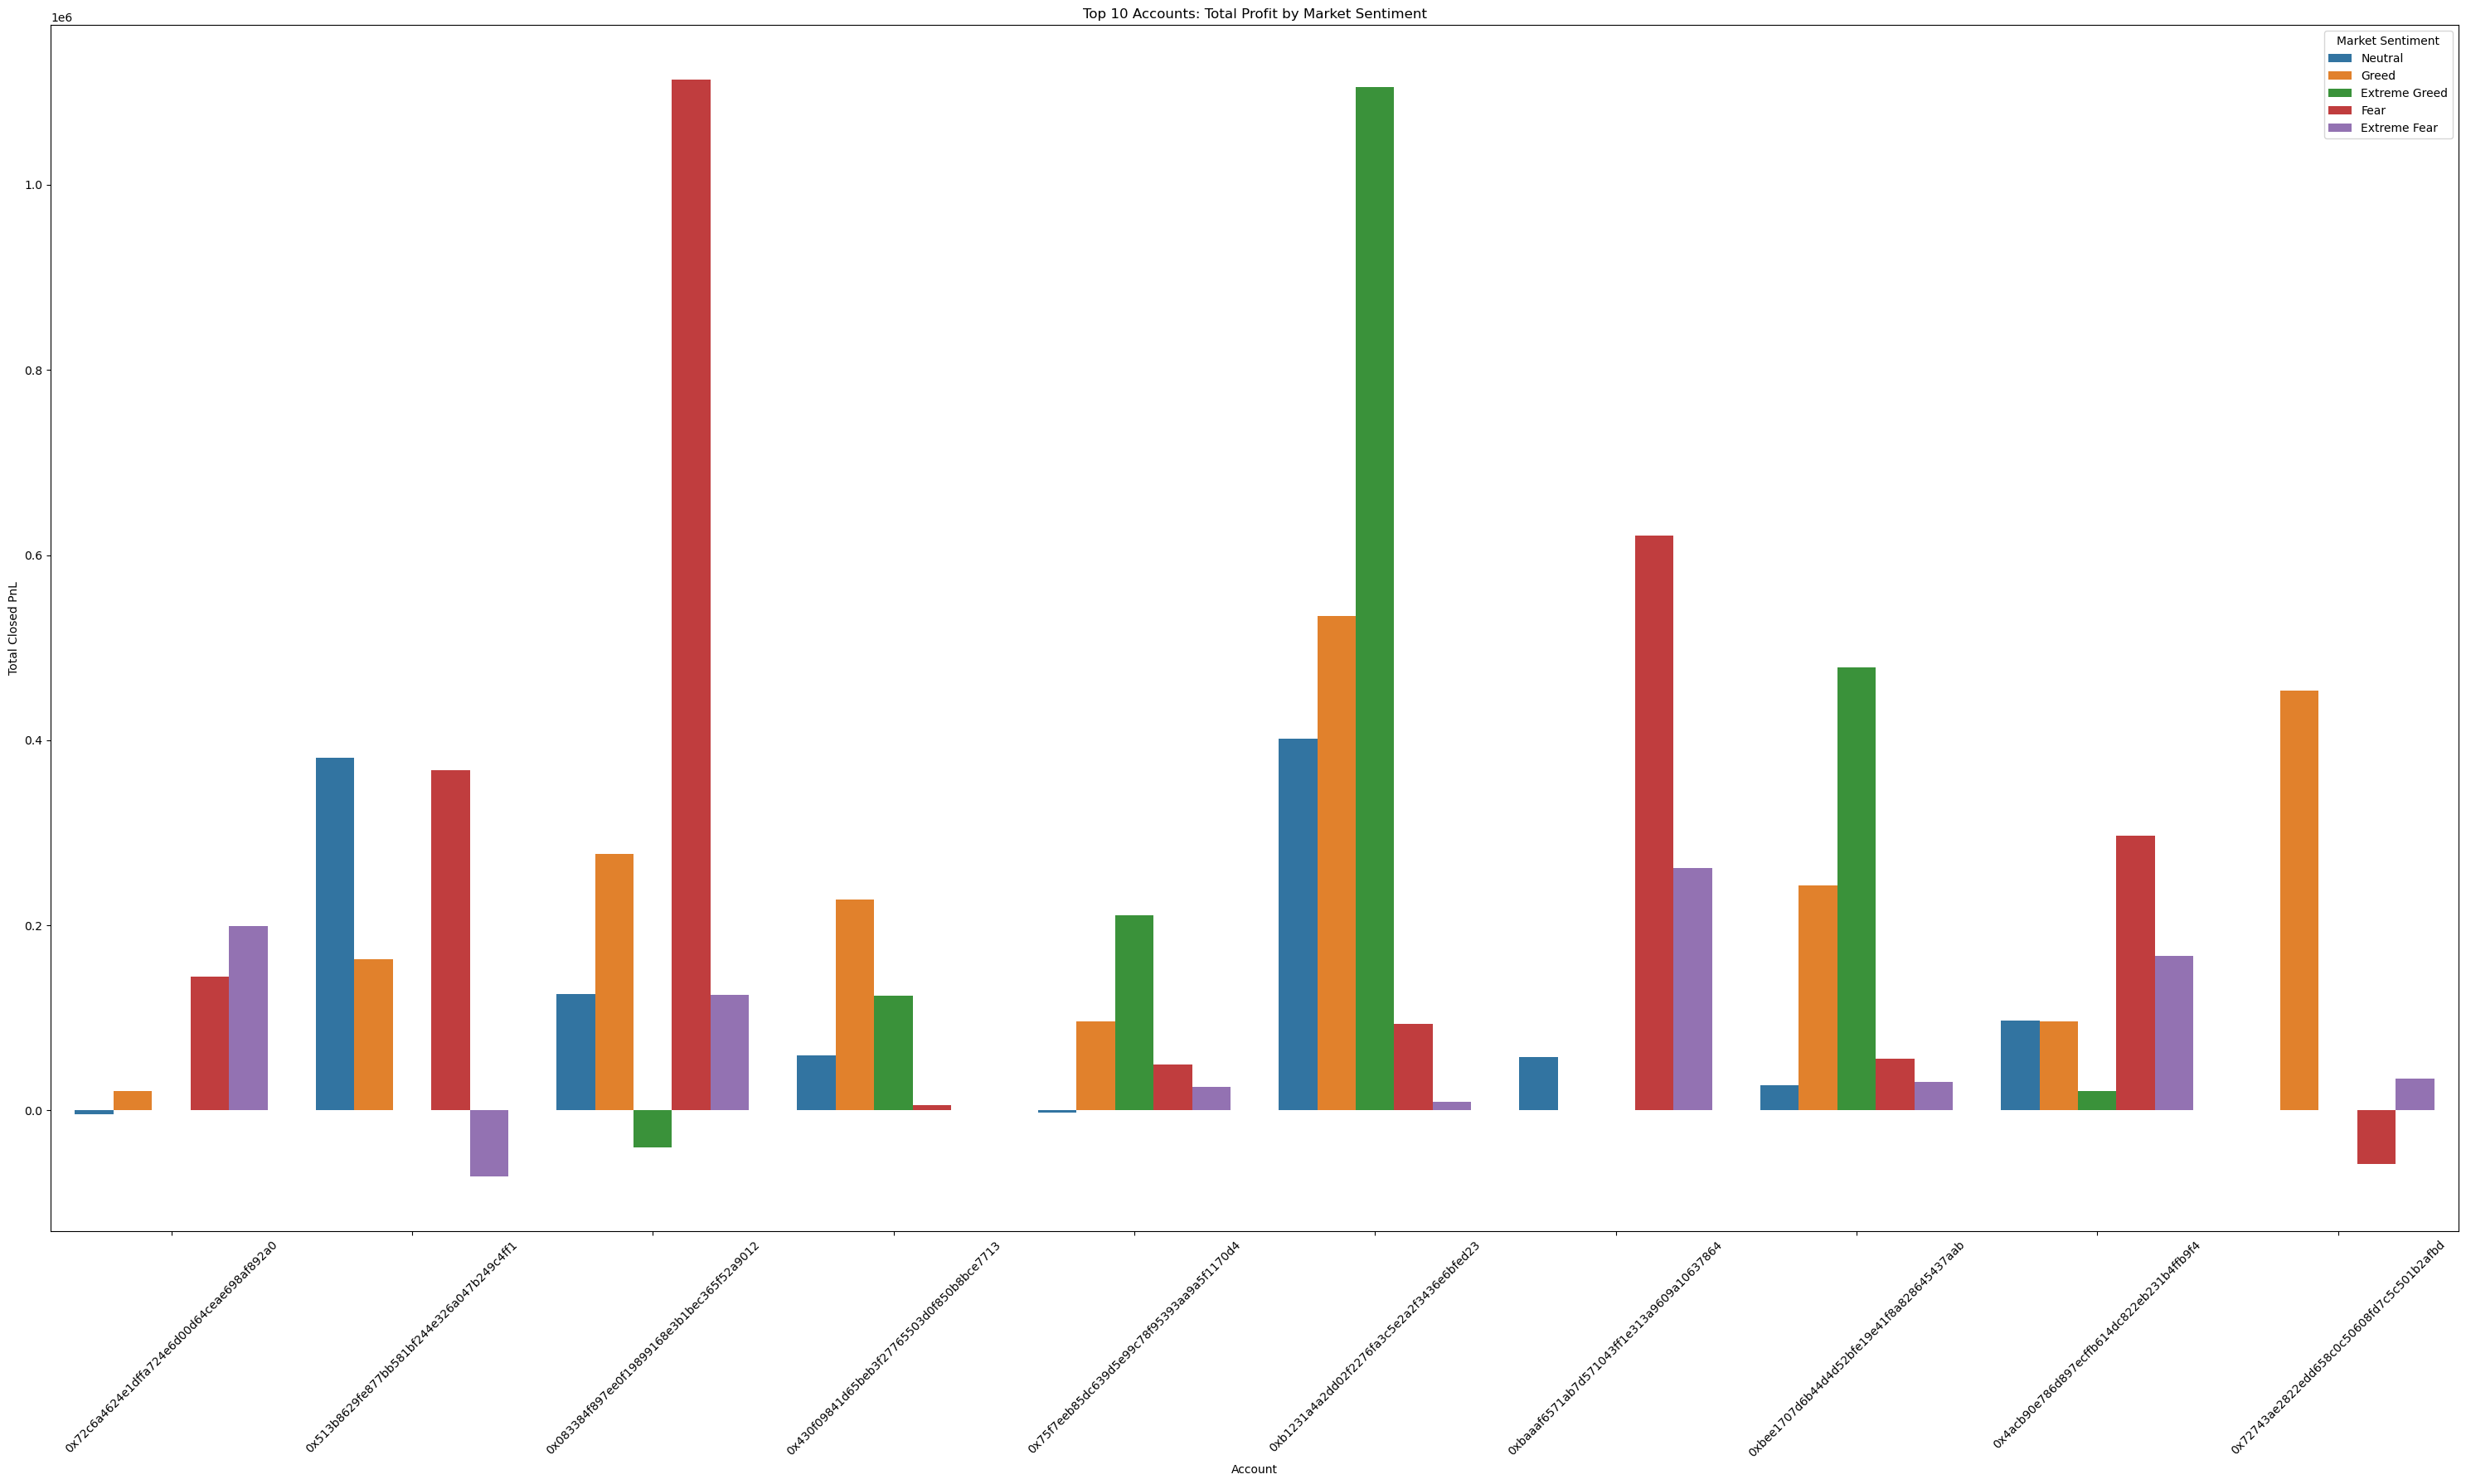

In [74]:
# Top 20 profitable accounts
top_accounts = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .nlargest(10)
    .index
)

top_data = merged[merged['Account'].isin(top_accounts)]

plt.figure(figsize=(30,18))

sns.barplot(
    data=top_data,
    x='Account',
    y='Closed PnL',
    hue='classification',
    estimator=sum,
    errorbar=None
)

plt.title('Top 10 Accounts: Total Profit by Market Sentiment')
plt.xlabel('Account')
plt.ylabel('Total Closed PnL')
plt.xticks(rotation=45)

plt.legend(title='Market Sentiment')
plt.tight_layout()
plt.show()

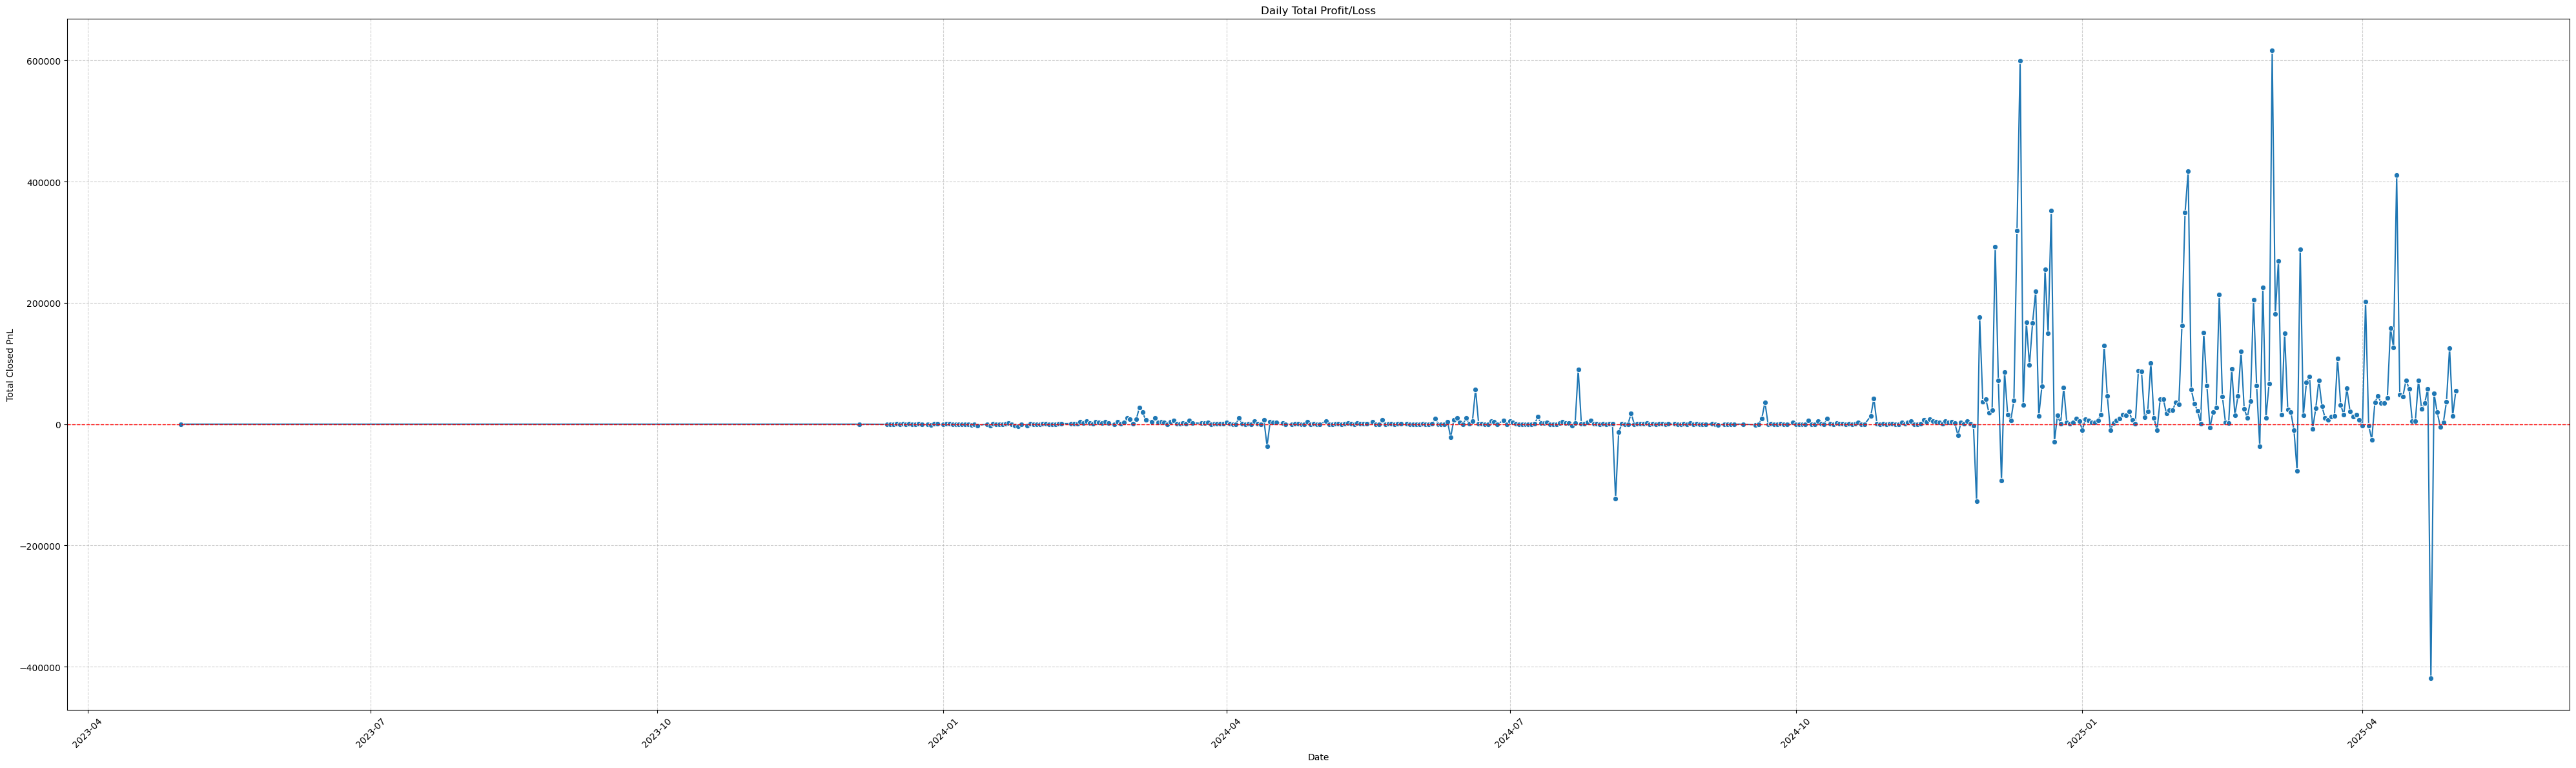

In [50]:
# Daily Profits

daily_profit = (
    merged.groupby('date')['Closed PnL']
    .sum()
    .reset_index()
)

plt.figure(figsize=(40,12))

sns.lineplot(
    data=daily_profit,
    x='date',
    y='Closed PnL',
    marker='o'
)

plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Daily Total Profit/Loss')
plt.xlabel('Date')
plt.ylabel('Total Closed PnL')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

<Axes: xlabel='classification'>

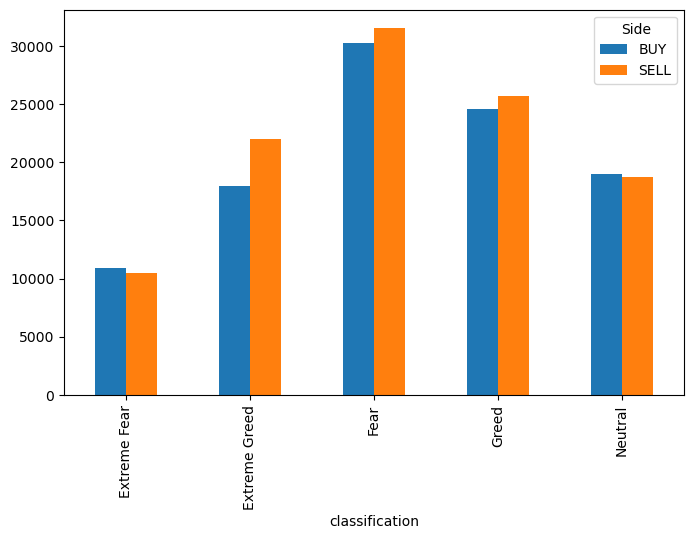

In [57]:
# Long vs Short

side = pd.crosstab(
    merged["classification"],
    merged["Side"]
)

side.plot(kind="bar", figsize=(8,5))

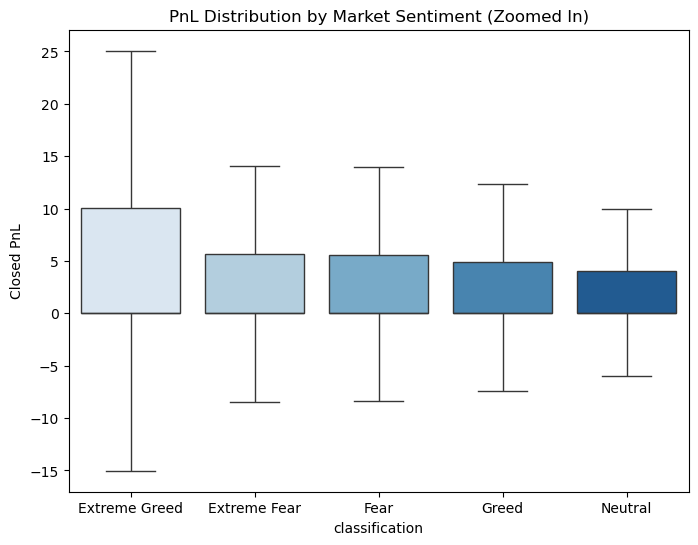

In [ ]:
# Profit Distribution (Boxplot)
plt.figure(figsize=(8,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL",
    hue="classification", 
    palette='Blues',      
    legend=False,
    showfliers=False    
)

plt.title("PnL Distribution by Market Sentiment (Zoomed In)")
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

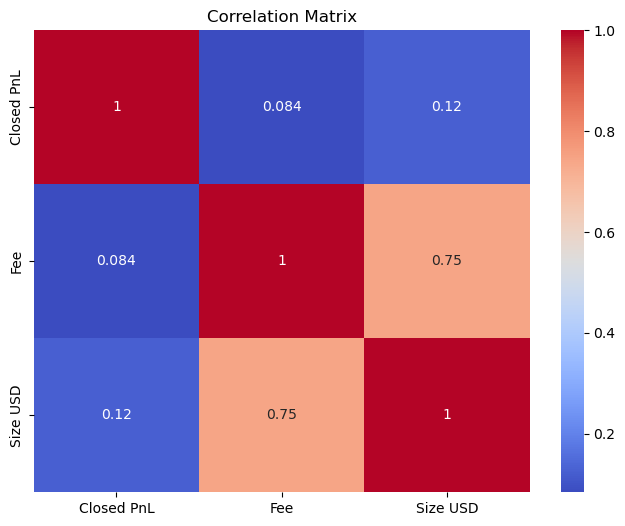

In [68]:
# Corelation Matrix
plt.figure(figsize=(8,6))

corr = merged[
    [
        "Closed PnL",
        "Fee",
        "Size USD"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

## Final Insights and Conclusion

### Relationship Between Market Sentiment and Trader Performance



##### 1. Trading activity is highest during Fear and Greed Markets.

<font size='3'>The sentiment distribution shows that **Fear** (61,837 trades) and **Greed** (50,303 trades) account for the majority of trading activity, while Extreme Fear (21,400 trades) has the fewest trades. This suggests that traders are generally more active during normal market conditions than during extreme bearish periods.</font>

##### 2. Extreme Greed produces the highest average profitability

<font size='3'>The average Closed PnL analysis indicates that **Extreme Greed** has the highest average profit per trade (≈68), followed by **Fear** (≈54). Extreme Fear and Neutral markets have the lowest average profits (≈35), suggesting that highly bullish market conditions provide the greatest profit opportunities on a per-trade basis.</font>

##### 3. Fear markets generate the highest overall profit.

<font size='3'>Although the average profit per trade is highest during Extreme Greed, the total cumulative Closed PnL is highest during Fear (≈3.36 million), followed by Extreme Greed (≈2.72 million). This is largely due to the significantly larger number of trades executed during Fear periods.</font>

##### 4. Median trade profit remains zero across all sentiment classes.

<font size='3'>The median Closed PnL is 0 for every market sentiment category, indicating that at least half of the trades result in little or no realized profit. This suggests that overall profitability is driven primarily by a relatively small number of highly profitable trades rather than consistent gains across all trades.</font>

##### 5. Traders commit larger positions during Fear markets.

<font size='3'>The average trade size is highest during **Fear** (≈7,816 USD), followed by **Greed** (≈5,737 USD). This indicates that traders tend to allocate more capital during fearful market conditions, possibly expecting price reversals or attractive buying opportunities.</font>

##### 6. Trading fees increase with trade size.

<font size='3'>Average trading fees closely follow average trade sizes. **Fear** markets have both the **highest average** trade size and the **highest average** fees (≈1.50), while Extreme Greed has the lowest average fees (≈0.68). This reflects the expected relationship between larger positions and higher transaction costs.</font>

##### 7. Extreme Greed has the highest win rate.

<font size='3'>The win-rate analysis shows that **Extreme Greed has the highest proportion** of profitable trades (≈46%), followed by Fear (≈42%). Extreme Fear records the lowest win rate (≈37%), indicating that traders experience greater difficulty generating profitable trades during strongly bearish conditions.</font>

##### 8. Coin performance differs across market sentiment.
<font size='3'>The top-performing cryptocurrency varies depending on market sentiment. Coins such as **DOGE**, **ZRO**, and **AVAX** perform exceptionally well during **Neutral markets**, while **ENA** performs better during **Fear**. This suggests that different cryptocurrencies respond differently to changes in market sentiment, and no single asset consistently dominates across all conditions.</font>

##### 9. Top-performing traders adapt to different market conditions.

<font size='3'>The top ten accounts generate profits across multiple sentiment categories rather than relying on a single market condition. Several accounts perform exceptionally well during Fear, while others achieve their best performance during Greed or Neutral periods. This indicates that successful traders adapt their strategies to changing market environments rather than depending on one market regime.</font>

##### 10. Daily profitability is highly volatile.

<font size='3'>The daily profit trend reveals significant fluctuations over time, with occasional large profit spikes as well as periods of losses. This demonstrates that cryptocurrency trading returns are highly volatile and influenced by changing market conditions.</font>

##### 11. Buy and Sell activity remains relatively balanced.

<font size='3'>Across all market sentiment categories, BUY and SELL trades occur in similar proportions, although SELL orders slightly exceed BUY orders during Fear and Greed periods. This suggests that traders actively participate on both sides of the market rather than exhibiting strong directional bias.</font>

##### 12. Profit distribution contains substantial variability.

<font size='3'>The boxplot shows that profit distributions differ across market sentiments. Extreme Greed exhibits the widest spread of profits, indicating both higher upside potential and greater variability, whereas Neutral markets show comparatively smaller profit ranges.</font>

##### 13. Trade size strongly influences transaction fees but has only a weak relationship with profitability.

<font size='3'>The correlation matrix shows:
* Fee vs Size USD: 0.75 (strong positive correlation)
* Closed PnL vs Size USD: 0.12 (weak positive correlation)
* Closed PnL vs Fee: 0.08 (very weak positive correlation)

These results indicate that increasing trade size significantly increases trading costs but does not necessarily lead to proportionally higher profits.</font>

### Overall Conclusion
<font size='4'>
This analysis demonstrates that market sentiment has a measurable impact on trader behaviour and trading performance.
Key Observations include:

* Extreme Greed provides the highest average profit per trade and the highest win rate.
* Fear markets generate the largest cumulative profits due to substantially higher trading activity.
* Traders execute larger trades during Fear, resulting in higher transaction fees.
* Cryptocurrency performance varies by market sentiment, suggesting that asset selection should be adjusted according to prevailing market conditions.
* Successful traders remain profitable across multiple market environments rather than relying on a single sentiment regime.
* While larger trades incur higher fees, they do not guarantee higher profitability, highlighting the importance of risk management and trade quality over position size.
</font>